<h1><center>Laboratorio 9: Optimización de modelos 💯</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>

### **Cuerpo Docente:**

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: María Jesús Espinoza
- Nombre de alumno 2: Sofía Lazcano


### **Link de repositorio de GitHub:** https://github.com/jesuow/LabPro

### Temas a tratar

- Predicción de demanda usando `xgboost`
- Búsqueda del modelo óptimo de clasificación usando `optuna`
- Uso de pipelines.

### Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.
- Código que no se pueda ejecutar, no será revisado.

### Objetivos principales del laboratorio

- Optimizar modelos usando `optuna`
- Recurrir a técnicas de *prunning*
- Forzar el aprendizaje de relaciones entre variables mediante *constraints*
- Fijar un pipeline con un modelo base que luego se irá optimizando.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# Importamos librerias útiles

In [121]:
!pip install -qq xgboost optuna

# El emprendimiento de Fiu

Tras liderar de manera exitosa la implementación de un proyecto de ciencia de datos para caracterizar los datos generados en Santiago 2023, el misterioso corpóreo **Fiu** se anima y decide levantar su propio negocio de consultoría en machine learning. Tras varias e intensas negociaciones, Fiu logra encontrar su *primera chamba*: predecir la demanda (cantidad de venta) de una famosa productora de bebidas de calibre mundial. Al ver el gran potencial y talento que usted ha demostrado en el campo de la ciencia de datos, Fiu lo contrata como data scientist para que forme parte de su nuevo emprendimiento.

Para este laboratorio deben trabajar con los datos `sales.csv` subidos a u-cursos, el cual contiene una muestra de ventas de la empresa para diferentes productos en un determinado tiempo.

Para comenzar, cargue el dataset señalado y visualice a través de un `.head` los atributos que posee el dataset.

<i><p align="center">Fiu siendo felicitado por su excelente desempeño en el proyecto de caracterización de datos</p></i>
<p align="center">
  <img src="https://media-front.elmostrador.cl/2023/09/A_UNO_1506411_2440e.jpg">
</p>

In [122]:
import pandas as pd
import numpy as np
from datetime import datetime

df = pd.read_csv("sales.csv") #leer datos
df['date'] = pd.to_datetime(df['date']) # formatear date como datetime

df.head()

/tmp/ipykernel_240469/1940568124.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date']) # formatear date como datetime


,id,date,city,lat,long,pop,shop,brand,container,capacity,price,quantity
0,0,2012-01-31,Athens,37.97945,23.71622,672130,shop_1,kinder-cola,glass,500ml,0.96,13280
1,1,2012-01-31,Athens,37.97945,23.71622,672130,shop_1,kinder-cola,plastic,1.5lt,2.86,6727
2,2,2012-01-31,Athens,37.97945,23.71622,672130,shop_1,kinder-cola,can,330ml,0.87,9848
3,3,2012-01-31,Athens,37.97945,23.71622,672130,shop_1,adult-cola,glass,500ml,1.00,20050
4,4,2012-01-31,Athens,37.97945,23.71622,672130,shop_1,adult-cola,can,330ml,0.39,25696


## 1 Generando un Baseline (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/O-lan6TkadUAAAAC/what-i-wnna-do-after-a-baseline.gif">
</p>

Antes de entrenar un algoritmo, usted recuerda los apuntes de su magíster en ciencia de datos y recuerda que debe seguir una serie de *buenas prácticas* para entrenar correcta y debidamente su modelo. Después de un par de vueltas, llega a las siguientes tareas:

1. Separe los datos en conjuntos de train (70%), validation (20%) y test (10%). Fije una semilla para controlar la aleatoriedad. [0.5 puntos]
2. Implemente un `FunctionTransformer` para extraer el día, mes y año de la variable `date`. Guarde estas variables en el formato categorical de pandas. [1 punto]
3. Implemente un `ColumnTransformer` para procesar de manera adecuada los datos numéricos y categóricos. Use `OneHotEncoder` para las variables categóricas. `Nota:` Utilice el método `.set_output(transform='pandas')` para obtener un DataFrame como salida del `ColumnTransformer` [1 punto]
4. Guarde los pasos anteriores en un `Pipeline`, dejando como último paso el regresor `DummyRegressor` para generar predicciones en base a promedios. [0.5 punto]
5. Entrene el pipeline anterior y reporte la métrica `mean_absolute_error` sobre los datos de validación. ¿Cómo se interpreta esta métrica para el contexto del negocio? [0.5 puntos]
6. Finalmente, vuelva a entrenar el `Pipeline` pero esta vez usando `XGBRegressor` como modelo **utilizando los parámetros por default**. ¿Cómo cambia el MAE al implementar este algoritmo? ¿Es mejor o peor que el `DummyRegressor`? [1 punto]
7. Guarde ambos modelos en un archivo .pkl (uno cada uno) [0.5 puntos]

#capacity hay que pasarla a litros o ml todas

In [123]:
from sklearn.model_selection import train_test_split


# Dividir los datos en train, validation y test (70%, 20%, 10%)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
validation_df, test_df = train_test_split(temp_df, test_size=0.33, random_state=42)  # 0.33 * 0.3 ≈ 0.10

In [124]:
from sklearn.preprocessing import FunctionTransformer

# Función para extraer día, mes y año de la variable `date`
def extract_date_features(df):
    df['year'] = pd.to_datetime(df['date']).dt.year.astype('category')
    df['month'] = pd.to_datetime(df['date']).dt.month.astype('category')
    df['day'] = pd.to_datetime(df['date']).dt.day.astype('category')
    return df.drop(columns=['date'])

# Crear un transformer para las fechas
date_transformer = FunctionTransformer(extract_date_features)

In [125]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

train_df['capacity'] = train_df['capacity'].astype(str)

# Función para convertir la capacidad a mililitros
def convert_capacity_to_ml(X):
    X = X.copy()  # Asegura que no se modifique el original
    X = X.str.lower()  # Asegura que las unidades sean uniformes
    X_ml = X.apply(lambda x: float(x.replace('ml', '').replace('lt', '')) * 1000 if 'lt' in x else float(x.replace('ml', '')))
    return X_ml.values.reshape(-1, 1)

# Crear el FunctionTransformer para transformar la capacidad
capacity_transformer = FunctionTransformer(convert_capacity_to_ml)

# Definir las columnas numéricas y categóricas (ya que capacity se procesará antes)
numeric_features = ['lat', 'long', 'pop', 'price']
categorical_features = ['city', 'shop', 'brand', 'container', 'year', 'month', 'day']

# Crear el ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ('capacity_transform', capacity_transformer, 'capacity'),  # Transformar capacity a ml
        ('num', StandardScaler(), numeric_features),  # Escalar las variables numéricas
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Codificar las variables categóricas
    ]
)


In [126]:
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

# Crear el Pipeline
pipeline = Pipeline(steps=[
    ('date_transformer', date_transformer),  # Extraer año, mes y día
    ('preprocesamiento', col_transformer),  # Preprocesar los datos
    ('dummy_regressor', DummyRegressor(strategy="mean"))  # Regresor que predice el valor promedio
])

# Convertir la columna 'capacity' a string para asegurarse de que el FunctionTransformer funcione
train_df['capacity'] = train_df['capacity'].astype(str)
validation_df['capacity'] = validation_df['capacity'].astype(str)

In [127]:
# Separar las características (X) de la variable objetivo (y)
X_train = train_df.drop(columns='quantity')
y_train = train_df['quantity']

X_val = validation_df.drop(columns='quantity')
y_val = validation_df['quantity']

In [128]:
from sklearn.metrics import mean_absolute_error

pipeline.fit(X_train, y_train)


# Predecir sobre los datos de validación
validation_predictions = pipeline.predict(X_val)

# Calcular el MAE
mae_dummy = mean_absolute_error(y_val, validation_predictions)
print(f"Mean Absolute Error (DummyRegressor): {mae_dummy}")


Mean Absolute Error (DummyRegressor): 13308.134750658153


EL mae mide el promedio absoluto de los errores entre las predicciones y los valores reales, en este caso, en promedio el modelo se está equivocando 13308 de la variable objetivo (cantidad vendida) en cada predicción.

In [129]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Crear el Pipeline con XGBRegressor
pipeline_xgb = Pipeline(steps=[
    ('date_transformer', date_transformer),  # Extraer año, mes y día
    ('preprocesamiento', col_transformer),  # Preprocesar los datos
    ('xgb_regressor', XGBRegressor())  # Reemplazar con XGBRegressor
])

# Entrenar el pipeline con los datos de entrenamiento
pipeline_xgb.fit(train_df.drop(columns='quantity'), train_df['quantity'])

# Predecir sobre los datos de validación
validation_predictions_xgb = pipeline_xgb.predict(validation_df.drop(columns='quantity'))

# Calcular el MAE para XGBRegressor
mae_xgb = mean_absolute_error(validation_df['quantity'], validation_predictions_xgb)
print(f"Mean Absolute Error (XGBRegressor): {mae_xgb}")


Mean Absolute Error (XGBRegressor): 2417.044560553394


In [130]:
import joblib

# Guardar el modelo con DummyRegressor
joblib.dump(pipeline, 'dummy_regressor_pipeline.pkl')

# Guardar el modelo con XGBRegressor
joblib.dump(pipeline_xgb, 'xgb_regressor_pipeline.pkl')

print("Modelos guardados exitosamente.")


Modelos guardados exitosamente.


In [131]:
# Cargar el modelo desde archivo
loaded_dummy = joblib.load('dummy_regressor_pipeline.pkl')
loaded_xgb = joblib.load('xgb_regressor_pipeline.pkl')


## 2. Forzando relaciones entre parámetros con XGBoost (10 puntos)

<p align="center">
  <img src="https://64.media.tumblr.com/14cc45f9610a6ee341a45fd0d68f4dde/20d11b36022bca7b-bf/s640x960/67ab1db12ff73a530f649ac455c000945d99c0d6.gif">
</p>

Un colega aficionado a la economía le *sopla* que la demanda guarda una relación inversa con el precio del producto. Motivado para impresionar al querido corpóreo, se propone hacer uso de esta información para mejorar su modelo realizando las siguientes tareas:

1. Vuelva a entrenar el `Pipeline` con `XGBRegressor`, pero esta vez forzando una relación monótona negativa entre el precio y la cantidad. Para aplicar esta restricción apóyese en la siguiente <a href = https://xgboost.readthedocs.io/en/stable/tutorials/monotonic.html>documentación</a>. [6 puntos]

>Hint 1: Para implementar el constraint se le sugiere hacerlo especificando el nombre de la variable. De ser así, probablemente le sea útil **mantener el formato de pandas** antes del step de entrenamiento.

>Hint 2: Puede obtener el nombre de las columnas en el paso anterior al modelo regresor mediante el método `.get_feature_names_out()`

2. Luego, vuelva a reportar el `MAE` sobre el conjunto de validación. [1 puntos]

3. ¿Cómo cambia el error al incluir esta relación? ¿Tenía razón su amigo? [2 puntos]

4. Guarde su modelo en un archivo .pkl [1 punto]

In [132]:
print(train_df.columns)


Index(['id', 'date', 'city', 'lat', 'long', 'pop', 'shop', 'brand',
       'container', 'capacity', 'price', 'quantity'],
      dtype='object')


In [133]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import joblib
import pandas as pd

# Dividir los datos en train, validation y test (70%, 20%, 10%)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
validation_df, test_df = train_test_split(temp_df, test_size=0.33, random_state=42)  # 0.33 * 0.3 ≈ 0.10

# Función para extraer día, mes y año de la variable date
def extract_date_features(df):
    df['year'] = pd.to_datetime(df['date']).dt.year.astype('category')
    df['month'] = pd.to_datetime(df['date']).dt.month.astype('category')
    df['day'] = pd.to_datetime(df['date']).dt.day.astype('category')
    return df.drop(columns=['date'])

# Crear un transformer para las fechas
date_transformer = FunctionTransformer(extract_date_features)

# Función para convertir la capacidad a mililitros
def convert_capacity_to_ml(X):
    X = X.copy()  # Asegura que no se modifique el original
    X = X.str.lower()  # Asegura que las unidades sean uniformes
    X_ml = X.apply(lambda x: float(x.replace('ml', '').replace('lt', '')) * 1000 if 'lt' in x else float(x.replace('ml', '')))
    return X_ml.values.reshape(-1, 1)

# Crear el FunctionTransformer para transformar la capacidad
capacity_transformer = FunctionTransformer(convert_capacity_to_ml)

# Definir las columnas numéricas y categóricas
numeric_features = ['lat', 'long', 'pop', 'price']
categorical_features = ['city', 'shop', 'brand', 'container', 'year', 'month', 'day']

# Crear el ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ('capacity_transform', capacity_transformer, 'capacity'),  # Transformar capacity a ml
        ('num', StandardScaler(), numeric_features),  # Escalar las variables numéricas
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Codificar las variables categóricas
    ]
)

# Función para obtener los nombres de las características después de la transformación
def feat_names(x):
    temp_pipeline = Pipeline(steps=[
        ('date_transform', date_transformer),
        ('preprocessor', col_transformer)
    ])
    temp_pipeline.fit(x)
    feature_names = temp_pipeline.named_steps['preprocessor'].get_feature_names_out()
    return feature_names

# Crear el Pipeline con XGBRegressor aplicando una restricción monótona negativa en 'price'
xgb_pipeline = Pipeline(steps=[
    ('date_transform', date_transformer),
    ('preprocessor', col_transformer),
    ('model', XGBRegressor(monotonic_constraints=[0, 0, 0, -1, 0, 0, 0, 0, 0]))  # -1 en la posición de 'price'
])

# Separar las características (X) de la variable objetivo (y)
X_train = train_df.drop(columns='quantity')
y_train = train_df['quantity']

X_val = validation_df.drop(columns='quantity')
y_val = validation_df['quantity']

# Entrenar el pipeline con la restricción monótona negativa
xgb_pipeline.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de validación con el modelo actualizado
validation_predictions_xgb_constrained = xgb_pipeline.predict(X_val)

# Calcular el MAE para el modelo con la restricción monótona negativa
mae_xgb_constrained = mean_absolute_error(y_val, validation_predictions_xgb_constrained)
print(f'Mean Absolute Error on validation set with XGBRegressor (monotonic constraint): {mae_xgb_constrained}')

# Guardar el modelo con la restricción monótona negativa
joblib.dump(xgb_pipeline, 'xgb_regressor_constrained_pipeline.pkl')
print("Modelo guardado exitosamente.")




/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:08:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "monotonic_constraints" } are not used.

  warnings.warn(smsg, UserWarning)


Mean Absolute Error on validation set with XGBRegressor (monotonic constraint): 2417.044560553394
Modelo guardado exitosamente.


*3.¿Cómo cambia el error al incluir esta relación? ¿Tenía razón su amigo?*
El MAE es menor al incluir la relación, esto nos dice que nuestro amigo tenía razon en que la demanda guarda una relación inversa con el precio, pues al implementarla el error de predicción del modelo disminuyó.


## 3 Optimización de Hiperparámetros con Optuna (20 puntos)

<p align="center">
  <img src="https://media.tenor.com/fmNdyGN4z5kAAAAi/hacking-lucy.gif">
</p>

Luego de presentarle sus resultados, Fiu le pregunta si es posible mejorar *aun más* su modelo. En particular, le comenta de la optimización de hiperparámetros con metodologías bayesianas a través del paquete `optuna`. Como usted es un aficionado al entrenamiento de modelos de ML, se propone implementar la descabellada idea de su jefe.

A partir de la mejor configuración obtenida en la sección anterior, utilice `optuna` para optimizar sus hiperparámetros. En particular, se pide que su optimización considere lo siguiente:

- Fijar una semilla en las instancias necesarias para garantizar la reproducibilidad de resultados
- Utilice `TPESampler` como método de muestreo
- De `XGBRegressor`, optimice los siguientes hiperparámetros:
    - `learning_rate` buscando valores flotantes en el rango (0.001, 0.1)
    - `n_estimators` buscando valores enteros en el rango (50, 1000)
    - `max_depth` buscando valores enteros en el rango (3, 10)
    - `max_leaves` buscando valores enteros en el rango (0, 100)
    - `min_child_weight` buscando valores enteros en el rango (1, 5)
    - `reg_alpha` buscando valores flotantes en el rango (0, 1)
    - `reg_lambda` buscando valores flotantes en el rango (0, 1)
- De `OneHotEncoder`, optimice el hiperparámetro `min_frequency` buscando el mejor valor flotante en el rango (0.0, 1.0)

Para ello se pide los siguientes pasos:
1. Implemente una función `objective()` que permita minimizar el `MAE` en el conjunto de validación. Use el método `.set_user_attr()` para almacenar el mejor pipeline entrenado. [10 puntos]
2. Fije el tiempo de entrenamiento a 5 minutos. [1 punto]
3. Optimizar el modelo y reportar el número de *trials*, el `MAE` y los mejores hiperparámetros encontrados. ¿Cómo cambian sus resultados con respecto a la sección anterior? ¿A qué se puede deber esto? [3 puntos]
4. Explique cada hiperparámetro y su rol en el modelo. ¿Hacen sentido los rangos de optimización indicados? [5 puntos]
5. Guardar su modelo en un archivo .pkl [1 punto]

In [134]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Fijar la semilla para reproducibilidad
SEED = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Definir la función objetivo
def objective(trial):
    # Definir los hiperparámetros a ajustar
    xgb_params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'max_leaves': trial.suggest_int('max_leaves', 0, 100),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1)
    }

    # Crear el transformer de fechas
    date_transformer = FunctionTransformer(extract_date_features)
    
    # Crear el ColumnTransformer para preprocesamiento
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=trial.suggest_float('min_frequency', 0.0, 1.0)), categorical_features)
        ]
    )

    # Crear y entrenar el modelo XGBRegressor con los hiperparámetros dados
    model = XGBRegressor(**xgb_params, random_state=SEED)

    # Crear el pipeline
    pipeline = Pipeline(steps=[
        ('date_transform', date_transformer),
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Entrenar el pipeline con los datos de entrenamiento
    pipeline.fit(X_train, y_train)

    # Predecir sobre el conjunto de validación y calcular el MAE
    y_pred = pipeline.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)

    return mae

# Ejecutar la optimización con Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, timeout=300, show_progress_bar=True)

# Obtener el MAE y los mejores hiperparámetros encontrados
best_mae = study.best_value
best_params = study.best_params
num_trials = len(study.trials)

# Imprimir resultados
print(f'Número de trials: {num_trials}')
print(f'MAE: {best_mae}')
print('Mejores hiperparámetros encontrados:')
for key, value in best_params.items():
    print(f'{key}: {value}')

# Guardar el mejor modelo en un archivo .pkl
import joblib

# Crear el modelo final con los mejores hiperparámetros
best_model = XGBRegressor(**best_params, random_state=SEED)
final_pipeline = Pipeline(steps=[
    ('date_transform', date_transformer),
    ('preprocessor', col_transformer),
    ('regressor', best_model)
])

# Ajustar el pipeline con los datos de entrenamiento
final_pipeline.fit(X_train, y_train)

# Guardar el modelo
joblib.dump(final_pipeline, 'optimized_xgb_pipeline.pkl')
print("Modelo guardado exitosamente.")


Best trial: 142. Best value: 1938.89:  100%|██████████| 05:18/05:00


Número de trials: 152
MAE: 1938.887598666712
Mejores hiperparámetros encontrados:
learning_rate: 0.06773204030392392
n_estimators: 957
max_depth: 8
max_leaves: 98
min_child_weight: 4
reg_alpha: 0.2994088063476037
reg_lambda: 0.5329194967958708
min_frequency: 0.030553153554865067


/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:13:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "min_frequency" } are not used.

  warnings.warn(smsg, UserWarning)


Modelo guardado exitosamente.


*3. ¿Cómo cambian sus resultados con respecto a la sección anterior? ¿A qué se puede deber esto?* El error disminuye con respecto a los modelos anteriores, esto puede deberse a que al optimizar hiperparámetros el modelo ahora está mejor ajustado a las características específicas de los datos, resultando en un menor error promedio de predicción.

*Explique cada hiperparámetro y su rol en el modelo. ¿Hacen sentido los rangos de optimización indicados?*

Los hiperparametros utilizados fueron:
- learning_rate: Controla la velocidad de aprendizaje del modelo; un valor bajo permite ajustes más precisos.
- n_estimators: Número de árboles; más árboles pueden mejorar el ajuste pero aumentan el riesgo de sobreajuste.
- max_depth: Profundidad máxima de cada árbol; árboles más profundos capturan más complejidad pero pueden sobreajustar.
- max_leaves: Límite en el número de hojas por árbol; restringe la complejidad del modelo.
- min_child_weight: Peso mínimo para dividir un nodo; evita divisiones basadas en pocos datos, reduciendo el sobreajuste.
- reg_alpha: Regularización L1; ayuda a reducir el sobreajuste forzando coeficientes a cero.
- reg_lambda: Regularización L2; penaliza grandes coeficientes para prevenir sobreajuste.
- min_frequency: Frecuencia mínima para categorías en OneHot; excluye categorías raras para evitar ruido en los datos.

Los rangos de optimización indicados hacen sentido pues forman un buen equilibrio entre precision y riesgo de sobreajuste

## 4. Optimización de Hiperparámetros con Optuna y Prunners (17 puntos)

<p align="center">
  <img src="https://i.pinimg.com/originals/90/16/f9/9016f919c2259f3d0e8fe465049638a7.gif">
</p>

Después de optimizar el rendimiento de su modelo varias veces, Fiu le pregunta si no es posible optimizar el entrenamiento del modelo en sí mismo. Después de leer un par de post de personas de dudosa reputación en la *deepweb*, usted llega a la conclusión que puede cumplir este objetivo mediante la implementación de **Prunning**.

Vuelva a optimizar los mismos hiperparámetros que la sección pasada, pero esta vez utilizando **Prunning** en la optimización. En particular, usted debe:

- Responder: ¿Qué es prunning? ¿De qué forma debería impactar en el entrenamiento? [2 puntos]
- Redefinir la función `objective()` utilizando `optuna.integration.XGBoostPruningCallback` como método de **Prunning** [10 puntos]
- Fijar nuevamente el tiempo de entrenamiento a 5 minutos [1 punto]
- Reportar el número de *trials*, el `MAE` y los mejores hiperparámetros encontrados. ¿Cómo cambian sus resultados con respecto a la sección anterior? ¿A qué se puede deber esto? [3 puntos]
- Guardar su modelo en un archivo .pkl [1 punto]

Nota: Si quieren silenciar los prints obtenidos en el prunning, pueden hacerlo mediante el siguiente comando:

```
optuna.logging.set_verbosity(optuna.logging.WARNING)
```

De implementar la opción anterior, pueden especificar `show_progress_bar = True` en el método `optimize` para *más sabor*.

Hint: Si quieren especificar parámetros del método .fit() del modelo a través del pipeline, pueden hacerlo por medio de la siguiente sintaxis: `pipeline.fit(stepmodelo__parametro = valor)`

Hint2: Este <a href = https://stackoverflow.com/questions/40329576/sklearn-pass-fit-parameters-to-xgboost-in-pipeline>enlace</a> les puede ser de ayuda en su implementación

In [ ]:
#!pip install optuna-integration[xgboost]

In [147]:
import numpy as np
import pandas as pd
import optuna
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from optuna.integration import XGBoostPruningCallback

# Establecer los registros de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.disable_default_handler()

# Función para extraer características de fecha
def extract_date_features(X):
    # Aquí implementa la lógica para extraer características de la fecha
    return X

# Función para obtener los nombres de las características
def get_feature_names(preprocessor):
    # Ajustar el preprocesador temporalmente para obtener los nombres de las características
    temp_pipeline = Pipeline(steps=[
        ('date_transform', date_transformer),
        ('preprocessor', preprocessor)
    ])

    temp_pipeline.fit(X_train)

    feature_names = temp_pipeline.named_steps['preprocessor'].get_feature_names_out().copy()
    feature_names = [name.replace('cat__', '') for name in feature_names]
    feature_names = [name.replace('num__', '') for name in feature_names]
    return feature_names

# Función para convertir a DataFrame
def todf(x):
    if isinstance(x, np.ndarray):
        df = pd.DataFrame(x, columns=get_feature_names(preprocessortri))
    else:
        df = pd.DataFrame(x.todense(), columns=get_feature_names(preprocessortri))
    return df

# Define la función objetivo
def objective(trial):
    # Definir los hiperparámetros a ajustar
    xgb_params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'max_leaves': trial.suggest_int('max_leaves', 0, 100),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'min_frequency': trial.suggest_float('min_frequency', 0.0, 1.0)  # Agregado aquí
    }

    # Crear el modelo XGBRegressor con los hiperparámetros dados
    modelxgb = XGBRegressor(
        **xgb_params, 
        random_state=42, 
        enable_categorical=True, 
        eval_metric="mae", 
        early_stopping_rounds=10,
        callbacks=[XGBoostPruningCallback(trial, "validation_0-mae")]
    )

    global preprocessortri
    # Definición del preprocesador
    preprocessortri = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=xgb_params['min_frequency']), categorical_features)
        ],
        remainder='passthrough'
    )

    # Definir la Pipeline
    pipelinexgb = Pipeline(steps=[
        ('date_transform', FunctionTransformer(extract_date_features)),
        ('preprocessor', preprocessortri),
        ('to_dataframe', FunctionTransformer(func=todf)),
        ('regressor', modelxgb)
    ])

    # Transformar los conjuntos de entrenamiento y validación
    X_train_tr = pipelinexgb[:-1].fit_transform(X_train)
    X_val_tr = pipelinexgb[:-1].transform(X_val)

    # Entrenar el pipeline con los datos de entrenamiento
    fitted = pipelinexgb[-1].fit(X_train_tr, y_train, eval_set=[(X_val_tr, y_val)])

    return fitted.best_score

# Ejecutar la optimización con Optuna
study2 = optuna.create_study(direction='minimize')
study2.optimize(objective, timeout=300, show_progress_bar=True)




   0%|          | 00:00/05:00


[W 2024-10-24 23:55:57,435] Trial 0 failed with parameters: {'learning_rate': 0.0075751688981738965, 'n_estimators': 593, 'max_depth': 4, 'max_leaves': 84, 'min_child_weight': 4, 'reg_alpha': 0.4893455476573181, 'reg_lambda': 0.31140649504007256, 'min_frequency': 0.22375394399548731} because of the following error: ValueError('A given column is not a column of the dataframe').
Traceback (most recent call last):
  File "/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyEr

ValueError: A given column is not a column of the dataframe

## 5. Visualizaciones (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/F-LgB1xTebEAAAAd/look-at-this-graph-nickelback.gif">
</p>


Satisfecho con su trabajo, Fiu le pregunta si es posible generar visualizaciones que permitan entender el entrenamiento de su modelo.

A partir del siguiente <a href = https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/005_visualization.html#visualization>enlace</a>, genere las siguientes visualizaciones:

1. Gráfico de historial de optimización [1 punto]
2. Gráfico de coordenadas paralelas [1 punto]
3. Gráfico de importancia de hiperparámetros [1 punto]

Comente sus resultados:

4. ¿Desde qué *trial* se empiezan a observar mejoras notables en sus resultados? [0.5 puntos]
5. ¿Qué tendencias puede observar a partir del gráfico de coordenadas paralelas? [1 punto]
6. ¿Cuáles son los hiperparámetros con mayor importancia para la optimización de su modelo? [0.5 puntos]

In [145]:
print(study2.trials_dataframe())


   number value             datetime_start          datetime_complete  \
0       0  None 2024-10-24 23:27:29.508129 2024-10-24 23:27:29.640100   

                duration  params_learning_rate  params_max_depth  \
0 0 days 00:00:00.131971              0.011087                 7   

   params_max_leaves  params_min_child_weight  params_min_frequency  \
0                 62                        5              0.763607   

   params_n_estimators  params_reg_alpha  params_reg_lambda state  
0                  678          0.317382           0.196488  FAIL  


In [146]:
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances

# Gráfico de historial de optimización
plot_optimization_history(study2).show()

# Gráfico de coordenadas paralelas
plot_parallel_coordinate(study2).show()

# Gráfico de importancia de hiperparámetros
plot_param_importances(study2).show()



[W 2024-10-24 23:52:33,832] There are no complete trials.


[W 2024-10-24 23:52:33,954] Your study does not have any completed trials.


[W 2024-10-24 23:52:33,964] Study instance does not contain completed trials.


## 6. Síntesis de resultados (3 puntos)

Finalmente:

1. Genere una tabla resumen del MAE en el conjunto de validación obtenido en los 5 modelos entrenados desde Baseline hasta XGBoost con Constraints, Optuna y Prunning. [1 punto]
2. Compare los resultados de la tabla y responda, ¿qué modelo obtiene el mejor rendimiento? [0.5 puntos]
3. Cargue el mejor modelo, prediga sobre el conjunto de **test** y reporte su MAE. [0.5 puntos]
4. ¿Existen diferencias con respecto a las métricas obtenidas en el conjunto de validación? ¿Porqué puede ocurrir esto? [1 punto]

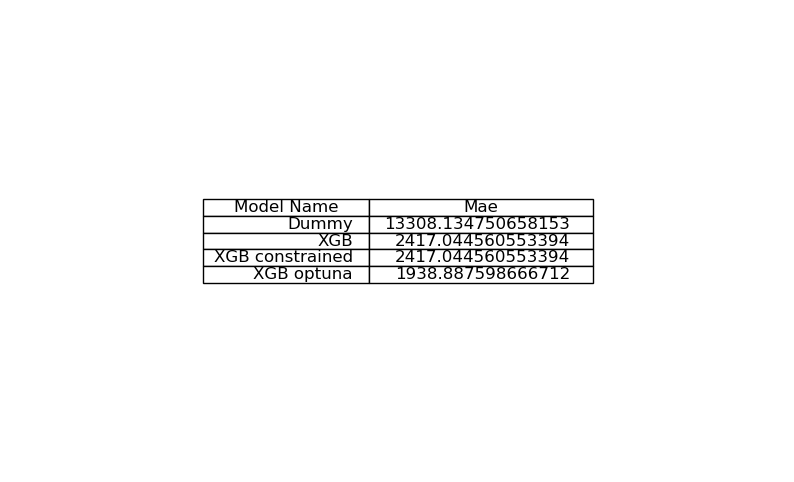

In [141]:
# Inserte su código acá
import matplotlib.pyplot as plt
metric_names = ['Model Name', 'Mae']
metric_values = [
    ['Dummy', mae_dummy],
    ['XGB', mae_xgb],
    ['XGB constrained', mae_xgb_constrained],
    ['XGB optuna', best_mae]
    #,['XGB optuna Callback', best_mae2]
]

# Crear una figura y un eje
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Ocultar los ejes
ax.axis('off')

# Crear una tabla
table2 = ax.table(cellText=metric_values, colLabels=metric_names, loc='center')

# Ajustar el tamaño de la fuente en la tabla
table2.auto_set_font_size(False)
table2.set_fontsize(12)

# Ajustar el ancho de las columnas
table2.auto_set_column_width(col=list(range(len(metric_names))))

# Mostrar la tabla
plt.show()

*2.Compare los resultados de la tabla y responda, ¿qué modelo obtiene el mejor rendimiento? *
basado en los errores absolutos medios obtenidos con cada modelo, el que tiene un mejor rendimiento es el cuarto modelo, el que se utiliza optimización de parámetros con optuna en donde el MAE es de 1938,88.

In [142]:
def objectiveX(trial,X,Y):
    # Definir los hiperparámetros a ajustar
    xgb_params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'max_leaves': trial.suggest_int('max_leaves', 0, 100),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1)
    }

    date_transformer = FunctionTransformer(extract_date_features)
    preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=trial.suggest_float('min_frequency', 0.0, 1.0)), categorical_features)
       ]
     )


    # Crear y entrenar el modelo XGBRegressor con los hiperparámetros dados
    model = XGBRegressor(**xgb_params, random_state=42)

    # Crear el pipeline
    pipeline = Pipeline(steps=[
        ('date_transform', date_transformer),
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Entrenar el pipeline con los datos de entrenamiento
    pipeline.fit(X_train, y_train)

    # Predecir sobre el conjunto de validación y calcular el MAE
    y_pred = pipeline.predict(X)
    mae = mean_absolute_error(Y, y_pred)

    return mae

FileNotFoundError: [Errno 2] No such file or directory: 'mejor_modelo.pkl'

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media.tenor.com/8CT1AXElF_cAAAAC/gojo-satoru.gif">
</p>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>